In [34]:
import numpy as np
from scipy.signal import find_peaks, butter, filtfilt, hilbert
from joblib import Parallel, delayed
import os
import mne
import DeepNeuralNetworkSleep.hdf5_files.Artefacts_Detection as A
import matplotlib.pyplot as plt
from scipy.signal import decimate
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
import pandas as pd

In [2]:
# Rodent Frequency bands
noise_band = [0,0.5]
delta_band = [0.5,5]
# theta_band = [6,10]
sigma_band = [11,17]
# beta_band = [22,30]
gamma_band = [8,12]
total_band = [0,30]

In [3]:
# Human frequency bands (AASM)
# noise_band = [0,0.49]
# delta_band = [0.5,3.99]
theta_band = [4,8]
alpha_band = [8,12]
# sigma_band = [12,15.99]
beta_band = [16,30]
# gamma_band = [30,40]
# total_band = [0,40]

### Functions

In [4]:
def psd_multitaper(lfp_data, fs, frequency_band):
    all_power_sum = []
    
    # loop through each segment
    for start in range(0, len(lfp_data) - window_length + 1, window_length):
        window = lfp_data[start:min(start + window_length, len(lfp_data))]

        # compute power spectral density using multitaper method
        psd, freqs = mne.time_frequency.psd_array_multitaper(window, fs, fmin=frequency_band[0], fmax=frequency_band[1], n_jobs=1, verbose = 'warning')

        # compute total power within frequency band
        freq_indices = (freqs >= frequency_band[0]) & (freqs <= frequency_band[1])
        curr_sum = np.sum(psd)
        all_power_sum.append(curr_sum)

    return all_power_sum

In [5]:
def index_W(theta, gamma, EMG):
  index_w = np.array([])
  for i in range(len(theta)):
    value = EMG[i]*EMG[i]*((gamma[i])/(theta[i]))
    index_w = np.append(index_w, [value])
  return index_w

def index_R(delta, sigma, EMG, eog_features):
    alt_index_r = np.array([])
    for i in range(len(delta)):
        value = (eog_features[i]*eog_features[i])/(EMG[i]*EMG[i]*delta[i]*sigma[i])
        alt_index_r = np.append(alt_index_r, [value])
        
    return alt_index_r

def index_N(eog_features, delta, alpha, EMG):
    alt_index_n = np.array([])
    for i in range(len(delta)):
        value = (eog_features[i]*delta[i])/(alpha[i]*EMG[i])
        alt_index_n = np.append(alt_index_n, [value])
        
    return alt_index_n


In [6]:
def normalized_cross_correlation(epoch1, epoch2):
    # zero-mean
    x = epoch1 - np.mean(epoch1)
    y = epoch2 - np.mean(epoch2)
    denom = np.sqrt(np.sum(x*x) * np.sum(y*y))
    if denom == 0:
        return 0.0
    return np.sum(x * y) / denom

def cross_correlation(EOG1, EOG2, epoch_length, fs, lag=0):
    samples = int(epoch_length * fs)
    out = []
    for i in range(0, len(EOG1) - len(EOG1) % samples, samples):
        e1 = EOG1[i:i + samples]
        e2 = EOG2[i:i + samples]
        # Use normalized cross-correlation (value in [-1,1])
        out.append(normalized_cross_correlation(e1, e2))
    return np.array(out)

def auto_correlation_slope(EOG, epoch_length, fs, min_slope_idx=1):
    samples = int(epoch_length * fs)
    slopes = []
    for i in range(0, len(EOG) - len(EOG) % samples, samples):
        epoch = EOG[i:i + samples]
        ac_full = np.correlate(epoch, epoch, mode='full')
        center = len(ac_full) // 2
        ac = ac_full[center:]  # non-negative lags
        # normalize ac so ac[0] == 1 (helps numeric stability)
        if ac[0] == 0:
            slopes.append(np.nan)
            continue
        ac = ac / ac[0]
        peaks, _ = find_peaks(ac)
        # find first peak with index >= min_slope_idx
        valid_peaks = [p for p in peaks if p >= min_slope_idx]
        if len(valid_peaks) < 1:
            slopes.append(np.nan)
            continue
        first_peak_idx = valid_peaks[0]
        # slope between lag 0 and first_peak_idx
        slope = (ac[first_peak_idx] - ac[0]) / first_peak_idx
        slopes.append(slope)
    return np.array(slopes)

def rem_feature(EOG1, EOG2, epoch_length, fs,
                slope_tol=1e-6, max_inv=1e6, clip_abs=None):
    # filter (check nyquist and signal length outside)
    nyq = 0.5 * fs
    low = 0.3 / nyq
    high = 35.0 / nyq
    if not (0 < low < 1 and 0 < high < 1 and low < high):
        raise ValueError("Filter cutoff frequencies invalid for fs={}".format(fs))
    b, a = butter(4, [low, high], btype='band')
    # be careful: filtfilt requires signal length > padlen (approx 3*max(len(a),len(b)))
    if len(EOG1) < 20 or len(EOG2) < 20:
        raise ValueError("Signals too short for reliable filtering.")
    EOG1_f = filtfilt(b, a, EOG1)
    EOG2_f = filtfilt(b, a, EOG2)

    cross_cor_val = cross_correlation(EOG1_f, EOG2_f, epoch_length, fs, 0)
    auto_slope = auto_correlation_slope(EOG1_f, epoch_length, fs)

    features = []
    for cc, slope in zip(cross_cor_val, auto_slope):
        if np.isnan(slope) or abs(slope) < slope_tol:
            inv = 0.0  # or np.nan depending on whether you want to keep epoch
        else:
            inv = 1.0 / slope
            # guard against absurdly large values
            if not np.isfinite(inv):
                inv = 0.0
            if max_inv is not None:
                if inv > max_inv:
                    inv = max_inv
                elif inv < -max_inv:
                    inv = -max_inv
        # keep sign of cross-corr but use normalized cc in [-1,1]
        feat = np.sign(cc) * inv
        features.append(feat)

    feats = np.array(features)
    if clip_abs is not None:
        feats = np.clip(feats, -clip_abs, clip_abs)
    return feats

def N_feature(EOG1, EOG2, epoch_length, fs):
    c_features = np.array([])
    EOG1 = decimate(EOG1, int(fs/50))
    EOG2 = decimate(EOG2, int(fs/50))
    fs = 50
    b, a = butter(4, [0.3 / (0.5 * fs), 0.45 / (0.5 * fs)], btype='band')
    EOG1 = filtfilt(b, a, EOG1)
    EOG2 = filtfilt(b, a, EOG2)
    cross_cor_val = cross_correlation(EOG1, EOG2, epoch_length, fs, 0)
    auto_corr_val = auto_correlation_slope(EOG1, epoch_length, fs)
    for count, ac in enumerate(auto_corr_val):
        feature = (1-ac) * cross_cor_val[count]
        c_features = np.append(c_features, feature)
    return c_features


In [7]:
def wei_normalizing(data):
    data = np.array(data)

    bottom = data[data <= np.nanpercentile(data, 10, axis=0)]
    top = data[data >= np.nanpercentile(data, 90, axis=0)]

    bottom_avg = np.average(bottom) if len(bottom) > 0 else 0
    top_avg = np.average(top) if len(top) > 0 else 1

    denom = top_avg - bottom_avg if top_avg != bottom_avg else 1
    normalized_data = (data - bottom_avg) / denom
    normalized_data = np.clip(normalized_data, 0.05, 1)

    return normalized_data

In [8]:
def fragment_join(subject, night, type):
    base = f"C:/EEG_Data_stage/{subject}/iEEG/{type}"
    score_base = f"C:/EEG_Data_stage/{subject}/iEEG/scores"
    files = []
    scores = []
    for file in os.listdir(base):
        if f"night{night}" in file and ".vhdr" in file:
            files.append(os.path.join(base,file))
            scores.append(os.path.join(score_base,file.replace(".vhdr", "_hypnogram.npy")))
    return files, scores        

### Establish parameters

In [9]:
subject = "7"
night = "2"
file_type = "converted_uni_and_bi"
# Channel to use for retrieving HPC bands
hpc_channel = 'TR10'
# Channel to use for retrieving PFC bands
pfc_channel = "TL01"
os.makedirs(os.path.join("C:/EEG_Data_stage","N_test_indices", file_type, subject, f"night{night}"), exist_ok=True)
output_dir = os.path.join("C:/EEG_Data_stage","N_test_indices", file_type, subject, f"night{night}")


In [10]:
fs = 250
epoch_length = 10 
window_length = epoch_length * fs

### Load data

In [11]:
files, scores_files = fragment_join(subject, night, file_type)
raw_list = [mne.io.read_raw_brainvision(f, preload=True) for f in files]
raw = mne.concatenate_raws(raw_list)
raw.filter(l_freq=10, h_freq=70, picks='EMG1-EMG2')
hpc_data = raw.get_data(picks=hpc_channel)[0]
hpc_tag = hpc_channel
raw_hpc = np.ravel(hpc_data)
pfc_data = raw.get_data(picks=pfc_channel)[0]
pfc_tag = pfc_channel
raw_pfc = np.ravel(pfc_data)

Extracting parameters from C:/EEG_Data_stage/7/iEEG/converted_uni_and_bi\7_night2_01.vhdr...
Setting channel info structure...
Reading 0 ... 2696415  =      0.000 ... 10785.660 secs...
Extracting parameters from C:/EEG_Data_stage/7/iEEG/converted_uni_and_bi\7_night2_02.vhdr...
Setting channel info structure...
Reading 0 ... 2343647  =      0.000 ...  9374.588 secs...
Extracting parameters from C:/EEG_Data_stage/7/iEEG/converted_uni_and_bi\7_night2_03.vhdr...
Setting channel info structure...
Reading 0 ... 2700015  =      0.000 ... 10800.060 secs...
Extracting parameters from C:/EEG_Data_stage/7/iEEG/converted_uni_and_bi\7_night2_04.vhdr...
Setting channel info structure...
Reading 0 ... 2699967  =      0.000 ... 10799.868 secs...
Filtering a subset of channels. The highpass and lowpass values in the measurement info will not be updated.
Filtering raw data in 4 contiguous segments
Setting up band-pass filter from 10 - 70 Hz

FIR filter parameters
---------------------
Designing a one-pa

In [12]:
score_list = [np.load(f) for f in scores_files]
states = np.concatenate(score_list)

In [13]:
EMG = raw.get_data(picks='EMG1-EMG2')[0]
EMG = EMG[:len(EMG)// (epoch_length * fs) * (epoch_length * fs)] 
EMG = EMG.reshape(-1, (epoch_length * fs))
EMG = EMG.sum(axis=1)
EMG = abs(hilbert(EMG))

### Artefact zeroing

In [14]:
amp_thresh = [10,5]         # 6σ for amplitude, 4σ for derivative
time_win_thresh = [0.2,0.1]
raw_hpc = A.removeArtefacts(raw_hpc, 250, amp_thresh, time_win_thresh)[0]
raw_pfc = A.removeArtefacts(raw_pfc, 250, amp_thresh, time_win_thresh)[0]

In [15]:
sleep_scoring = np.ravel(states)
score_labels = {0: 'Wake', 1: 'N1', 2:'N2', 3: 'N3', 4: 'REM'}
mapped_scores = np.array(sleep_scoring)
sleep_time_minutes = np.arange(0, len(sleep_scoring)) * epoch_length / 60
num_labels = {label: num for num, label in enumerate(score_labels.values(), start=1)}

In [16]:
### Get EOG
EOG1, EOG2 = np.ravel(raw.get_data(picks='EOG1')[0]), np.ravel(raw.get_data(picks='EOG2')[0])

In [17]:
epochs = np.arange(len(mapped_scores))
hypno_epochs = epochs

### Multicore power band calculation

In [18]:
raws = [np.ravel(raw_pfc), np.ravel(raw_pfc), np.ravel(raw_hpc), np.ravel(raw_pfc), np.ravel(raw_pfc), np.ravel(raw_pfc), np.ravel(raw_hpc)]
fr_bands = [noise_band, delta_band, theta_band, sigma_band, beta_band, gamma_band, alpha_band]
noise, delta, theta, sigma, beta, gamma, alpha = Parallel(n_jobs=7)(delayed(psd_multitaper)(raw, fs, band) for raw, band in zip(raws, fr_bands))

In [19]:
noise_norm = wei_normalizing(noise)
delta_norm = wei_normalizing(delta)
theta_norm = wei_normalizing(theta)
sigma_norm = wei_normalizing(sigma)
beta_norm = wei_normalizing(beta)
gamma_norm = wei_normalizing(gamma)
alpha_norm = wei_normalizing(alpha)
#total_norm = wei_normalizing(total)
EMG_norm = wei_normalizing(EMG)
noise_smoothed = np.convolve(np.convolve(np.convolve(noise_norm, np.ones(5)/5, mode='same'), np.ones(5)/5, mode='same'), np.ones(5)/5, mode='same')
theta_smoothed = np.convolve(np.convolve(np.convolve(theta_norm, np.ones(5)/5, mode='same'), np.ones(5)/5, mode='same'), np.ones(5)/5, mode='same')
delta_smoothed = np.convolve(np.convolve(np.convolve(delta_norm, np.ones(5)/5, mode='same'), np.ones(5)/5, mode='same'), np.ones(5)/5, mode='same')
alpha_smoothed = np.convolve(np.convolve(np.convolve(alpha_norm, np.ones(5)/5, mode='same'), np.ones(5)/5, mode='same'), np.ones(5)/5, mode='same')
beta_smoothed = np.convolve(np.convolve(np.convolve(beta_norm, np.ones(5)/5, mode='same'), np.ones(5)/5, mode='same'), np.ones(5)/5, mode='same')
sigma_smoothed = np.convolve(np.convolve(np.convolve(sigma_norm, np.ones(5)/5, mode='same'), np.ones(5)/5, mode='same'), np.ones(5)/5, mode='same')
gamma_smoothed = np.convolve(np.convolve(np.convolve(gamma_norm, np.ones(5)/5, mode='same'), np.ones(5)/5, mode='same'), np.ones(5)/5, mode='same')
EMG = np.convolve(EMG, np.ones(20*fs)/(20*fs), mode='same')

### Powerband plot


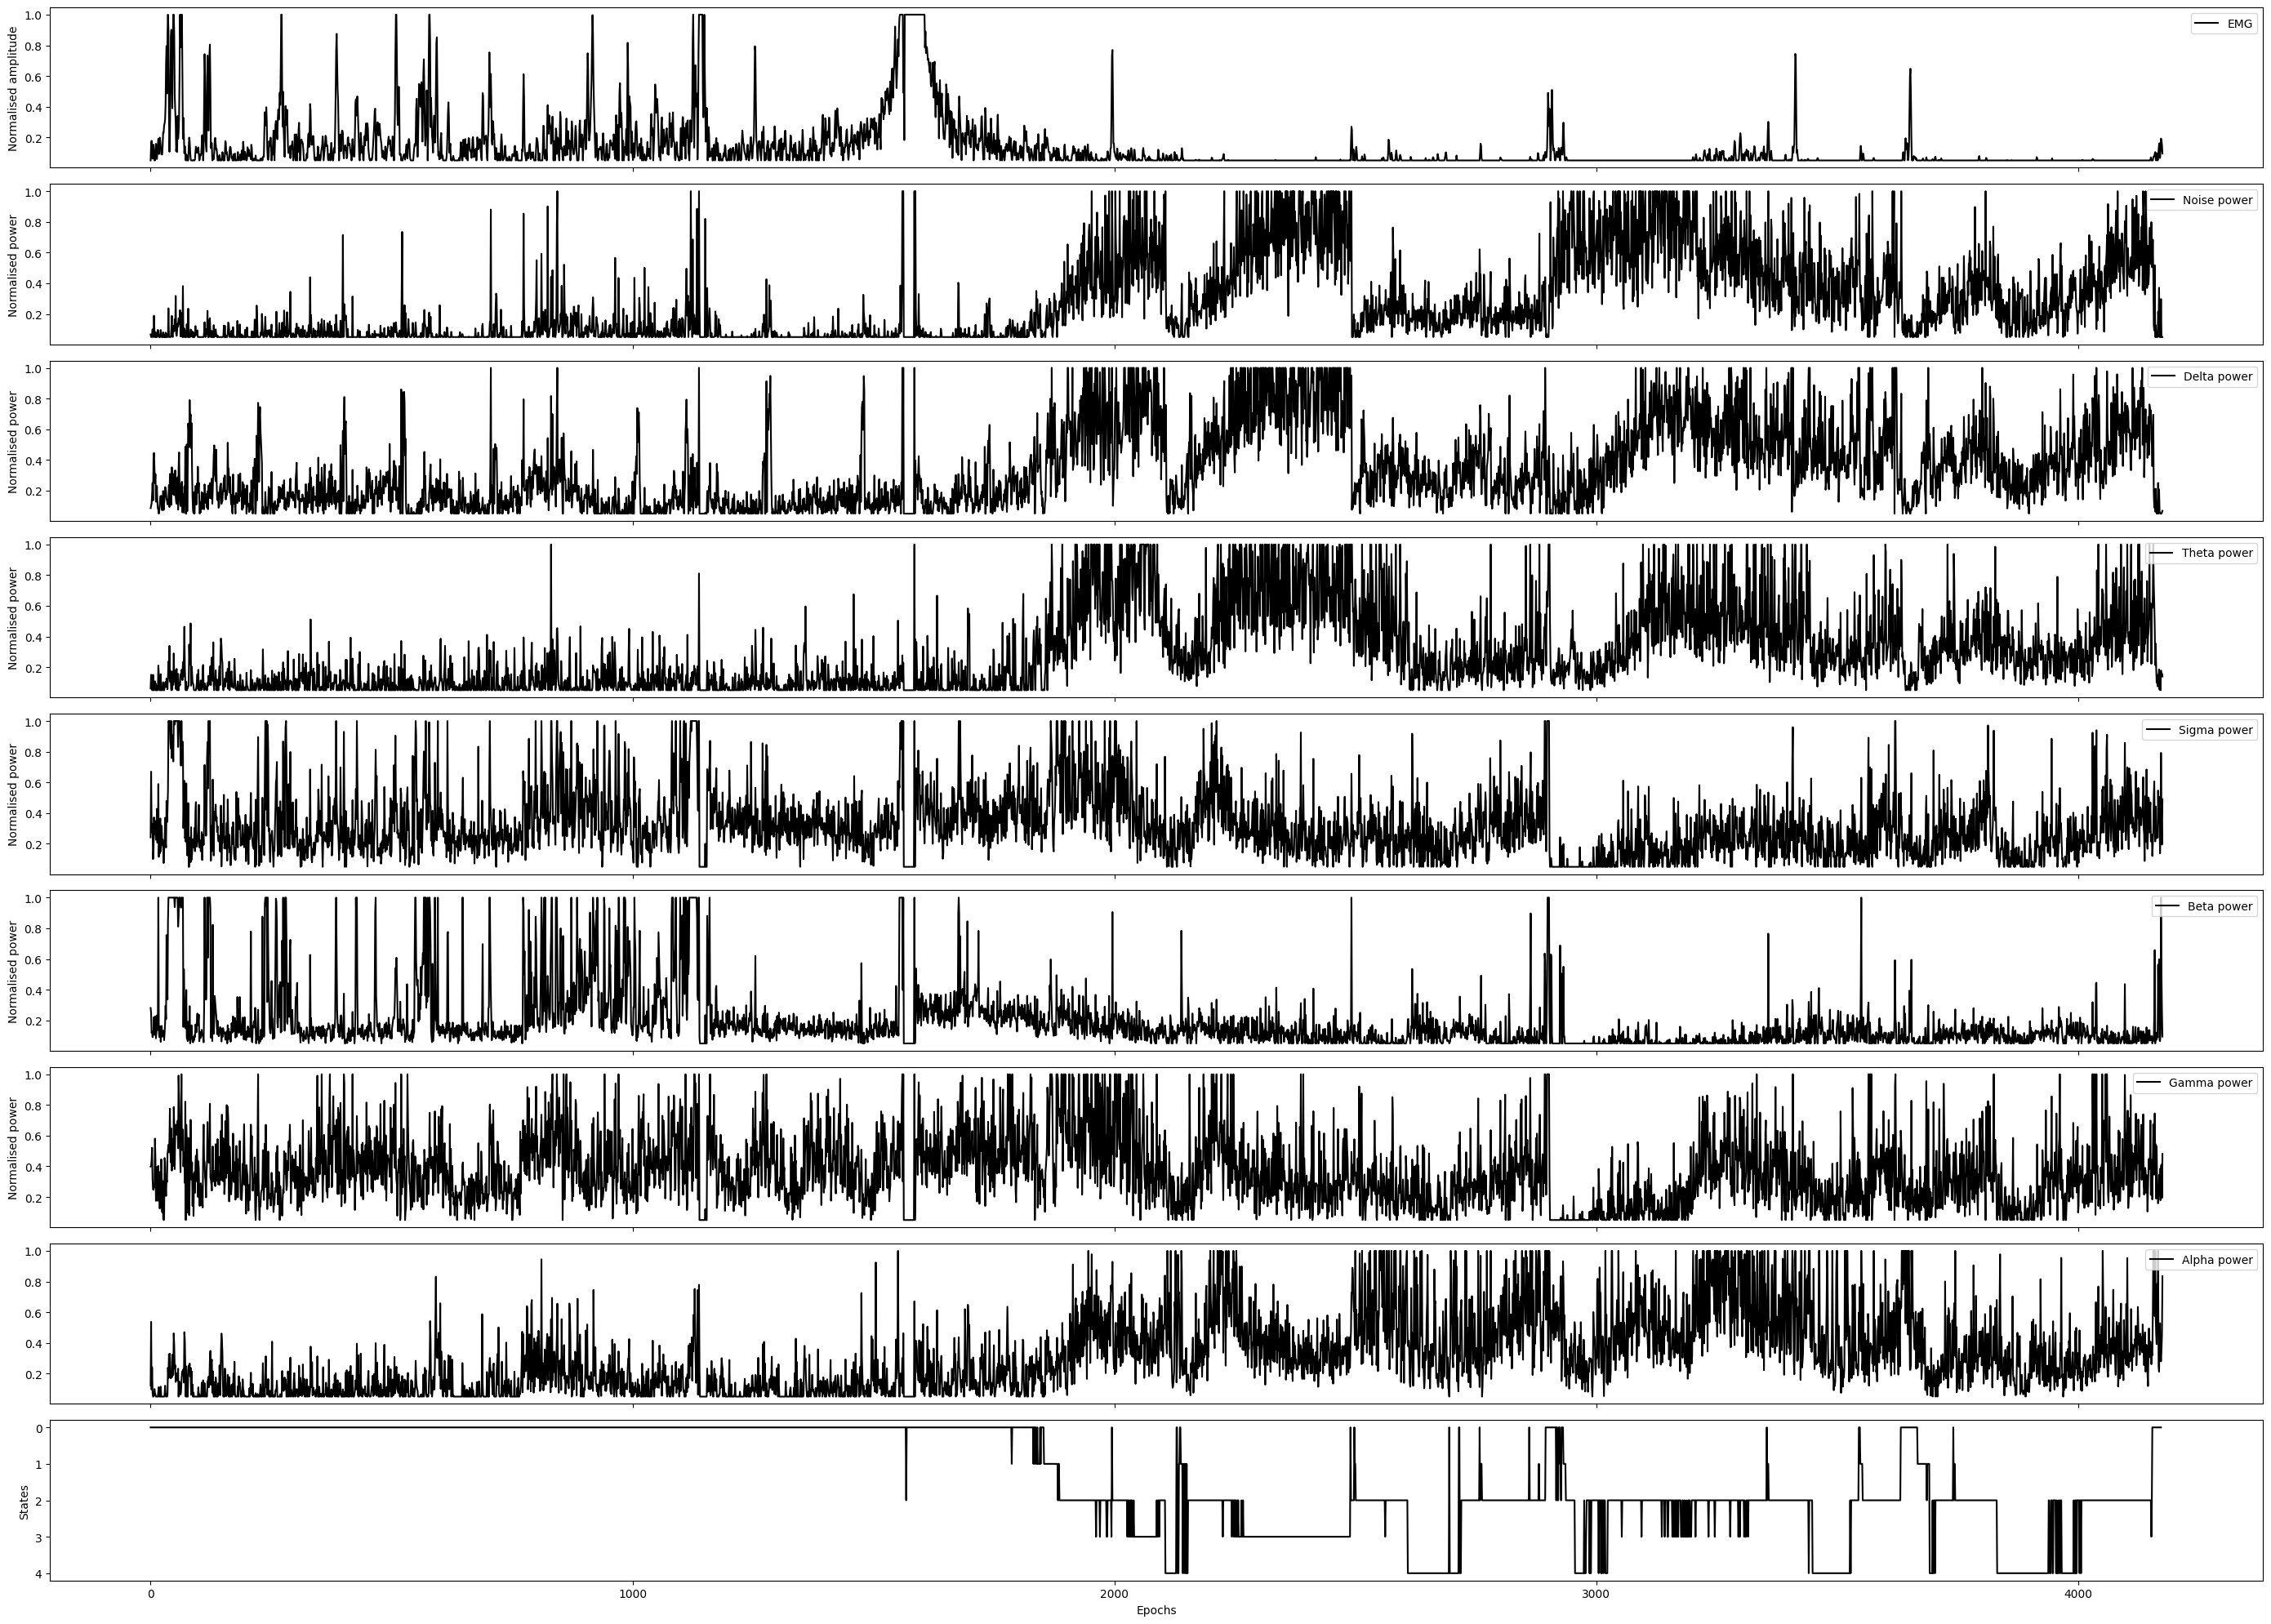

In [20]:
fig, (ax1, ax2, ax3, ax4, ax5, ax6, ax7, ax8, ax9) = plt.subplots(9, 1, sharex=True, figsize = (28, 20))
epochs = np.arange(len(EMG_norm))
# Plot data on each subplot
ax1.plot(epochs, EMG_norm, label='EMG', color = 'black')
ax2.plot(epochs, noise_norm, label='Noise power', color = 'black')
ax3.plot(epochs, delta_norm, label='Delta power', color = 'black')
ax4.plot(epochs, theta_norm, label='Theta power', color = 'black')
ax5.plot(epochs, sigma_norm, label='Sigma power', color = 'black')
ax6.plot(epochs, beta_norm, label='Beta power', color = 'black')
ax7.plot(epochs, gamma_norm, label='Gamma power', color = 'black')
ax8.plot(epochs, alpha_norm, label='Alpha power', color = 'black')
ax9.plot(hypno_epochs, sleep_scoring, label='Mapped scores', color = 'black')


ax1.legend(loc='upper right')
ax2.legend(loc='upper right')
ax3.legend(loc='upper right')
ax4.legend(loc='upper right')
ax5.legend(loc='upper right')
ax6.legend(loc='upper right')
ax7.legend(loc='upper right')
ax8.legend(loc='upper right')

ax1.set_ylabel('Normalised amplitude')
ax2.set_ylabel('Normalised power')
ax3.set_ylabel('Normalised power')
ax4.set_ylabel('Normalised power')
ax5.set_ylabel('Normalised power')
ax6.set_ylabel('Normalised power')
ax7.set_ylabel('Normalised power')
ax9.set_ylabel('States')
# ax8.set_yticks([0, 1, 2, 3, 4])
# ax8.set_yticklabels(state_labels)
ax9.invert_yaxis() 
ax9.set_xlabel('Epochs')
# Adjust layout to avoid overlap
plt.tight_layout()

plt.savefig(f"{output_dir}/Normalised_powers.svg", format='svg', dpi=300)
# Show the plots
plt.show()

C:\Users\timmi\AppData\Local\Temp\ipykernel_17204\63535414.py:7: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax1.legend()


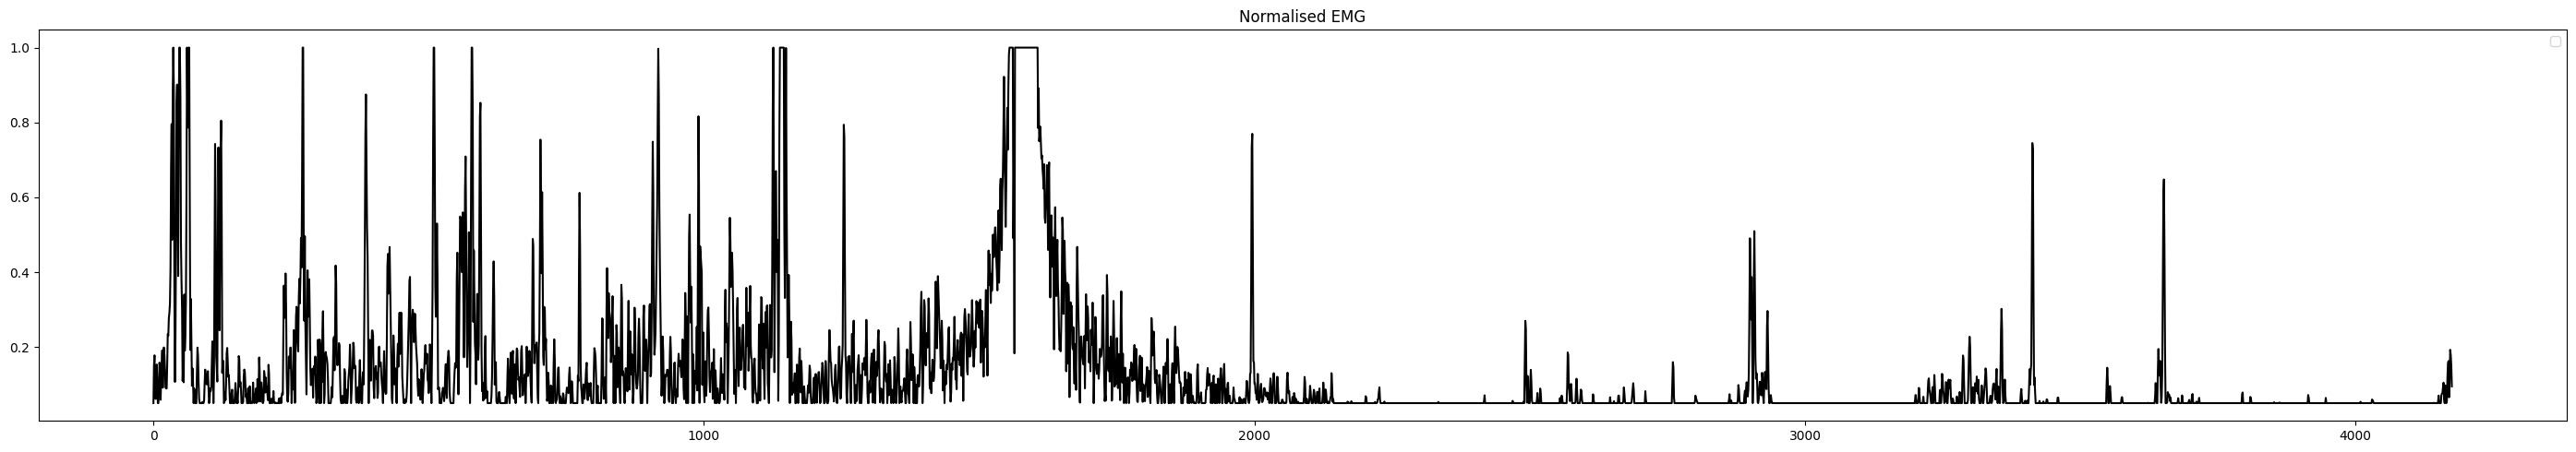

In [21]:

fig, (ax1) = plt.subplots(1, 1, sharex=True, figsize = (28, 5))

# Plot data on each subplot
ax1.plot(epochs, EMG_norm, label='', color = 'black')

# Add legends
ax1.legend()
ax1.set_title('Normalised EMG')
# Adjust layout to avoid overlap
plt.tight_layout()
plt.savefig(f"{output_dir}/Normalised_EMG.svg", format='svg', dpi=300)
# Show the plots
plt.show()

C:\Users\timmi\AppData\Local\Temp\ipykernel_17204\1084561901.py:22: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax1.legend()
C:\Users\timmi\AppData\Local\Temp\ipykernel_17204\1084561901.py:23: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax2.legend()
C:\Users\timmi\AppData\Local\Temp\ipykernel_17204\1084561901.py:24: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax3.legend()


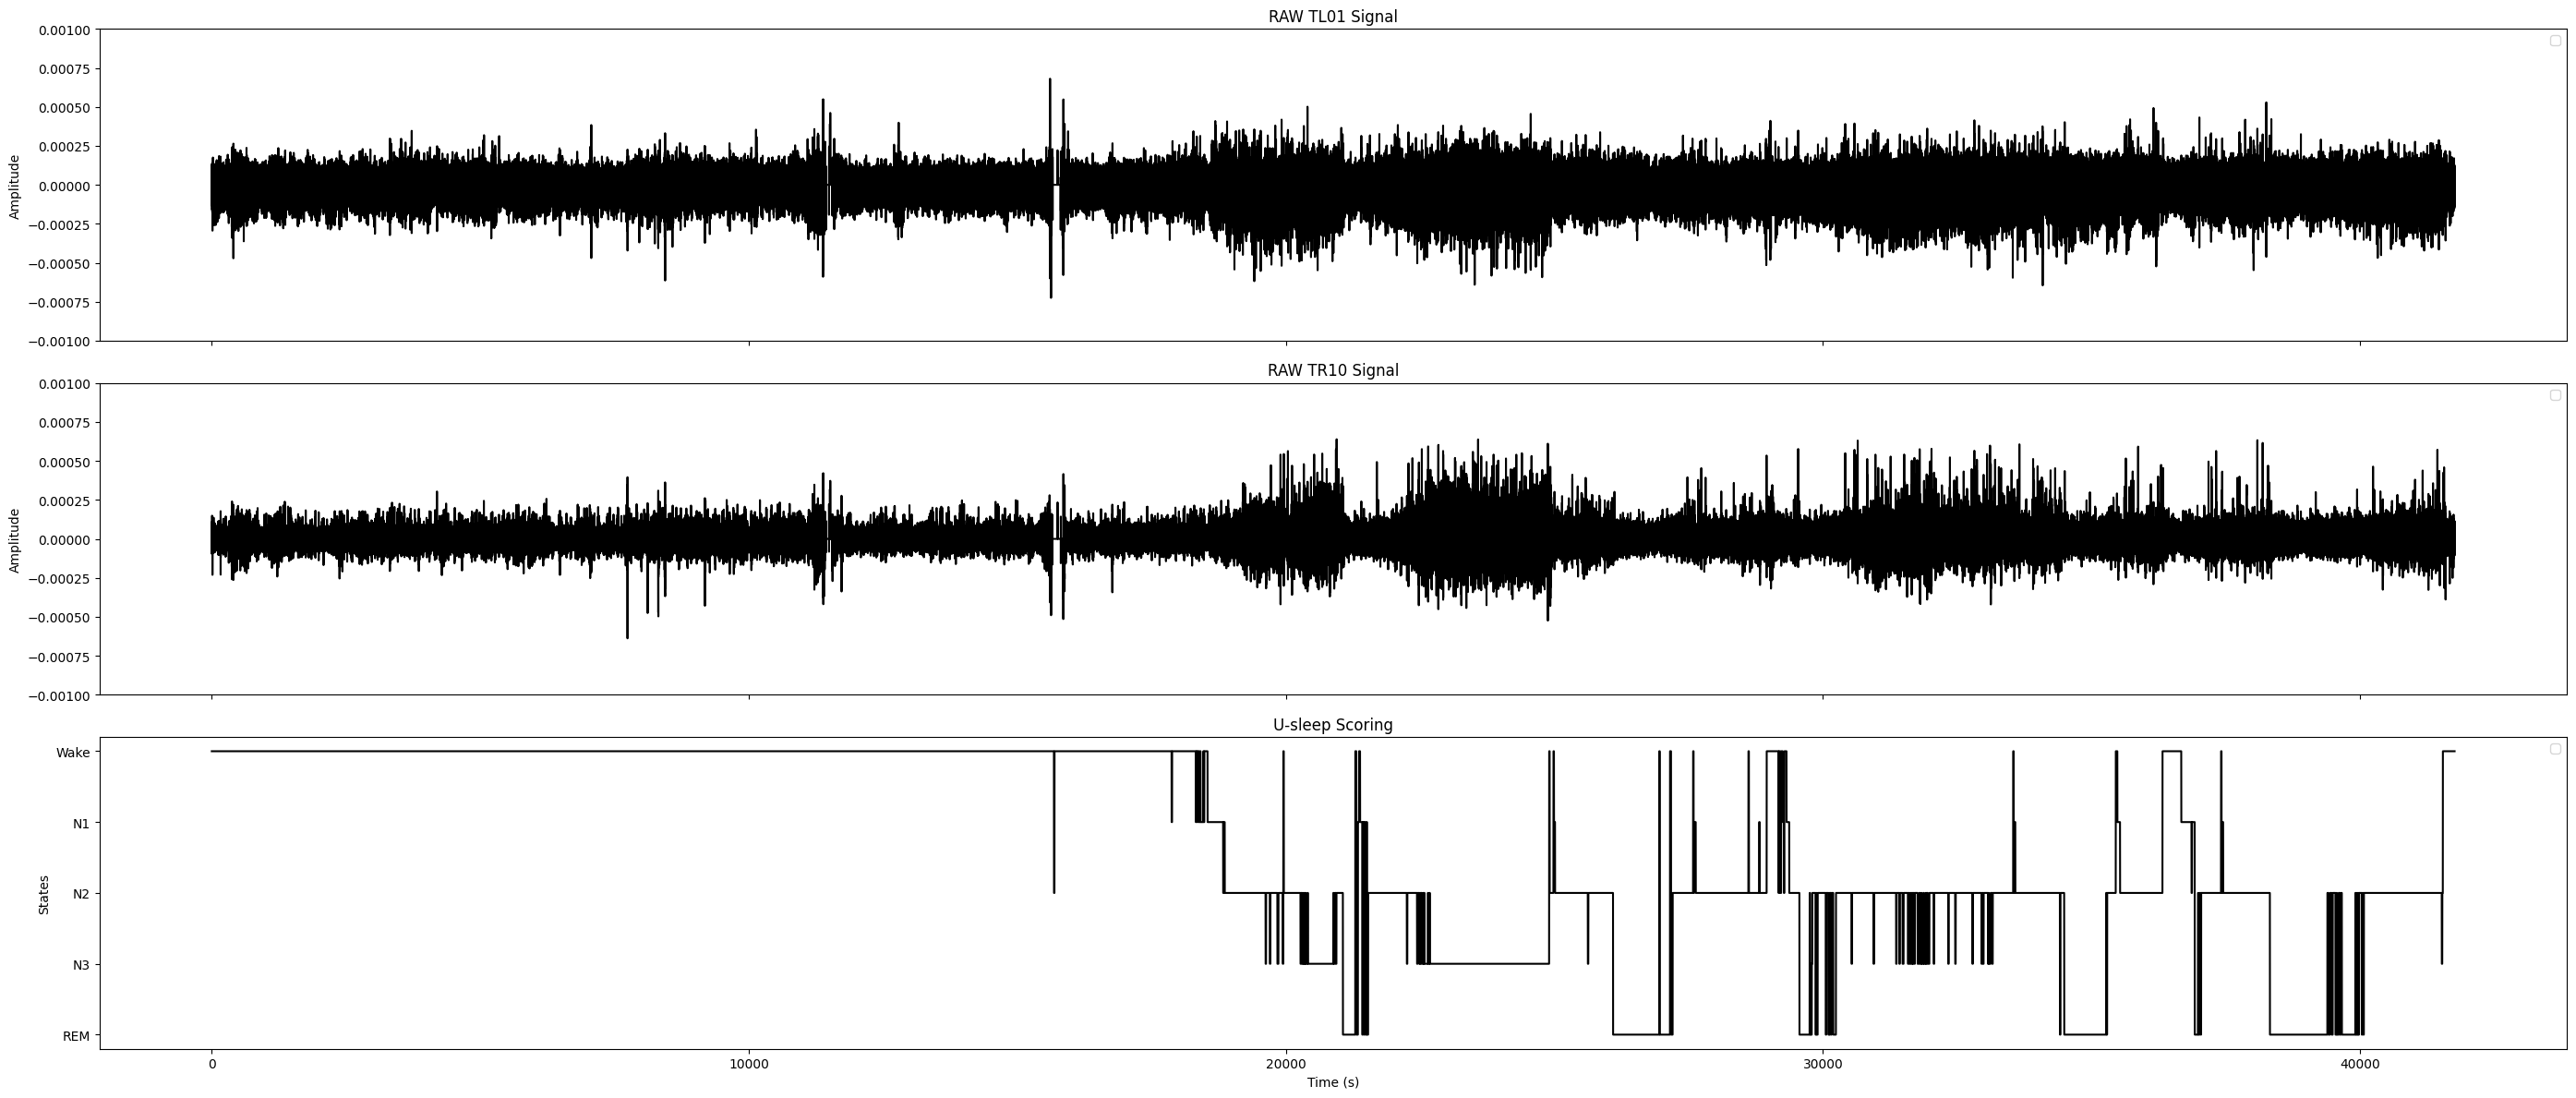

In [22]:
upsampled_states = np.repeat(states, 250 * 10)

target_len = len(raw_hpc)

if len(upsampled_states) < target_len:
    # pad with zeros
    pad_len = target_len - len(upsampled_states)
    upsampled_states = np.concatenate((upsampled_states, np.zeros(pad_len)))
elif len(upsampled_states) > target_len:
    # trim to match
    upsampled_states = upsampled_states[:target_len]
x = np.arange(len(raw_hpc))/250

fig, (ax1, ax2, ax3) = plt.subplots(3, 1, sharex=True, figsize=(28, 12))

# Plot data on each subplot
ax1.plot(x, raw_pfc, label='', color='black')
ax2.plot(x, raw_hpc, label='', color='black')
ax3.plot(x, upsampled_states, label='', color='black')

# Add legends
ax1.legend()
ax2.legend()
ax3.legend()

# Add axis titles
ax1.set_title(f'RAW {pfc_tag} Signal')
ax2.set_title(f'RAW {hpc_tag} Signal')
ax3.set_title('U-sleep Scoring')

ax1.set_ylabel('Amplitude')
ax2.set_ylabel('Amplitude')
ax3.set_ylabel('States')
ax3.set_xlabel('Time (s)')
state_labels = ['Wake', 'N1', 'N2', 'N3', 'REM']
ax3.set_yticks([0, 1, 2, 3, 4])
ax3.set_yticklabels(state_labels)
ax3.invert_yaxis() 
# Set y-axis limits (example values, adjust as needed)
ax1.set_ylim(-0.001, 0.001)  # Replace with appropriate limits for your data
ax2.set_ylim(-0.001, 0.001)  # Replace with appropriate limits for your data

# Adjust layout to avoid overlap
plt.tight_layout()
plt.savefig(f"{output_dir}/RAW_signals_Hypnogram.svg", format='svg', dpi=300)
# Show the plots
plt.show()

In [23]:
eog_features = rem_feature(EOG1, EOG2, epoch_length, fs)
eog_features = wei_normalizing(eog_features)
eog_features = np.convolve(
    np.convolve(
        np.convolve(eog_features, np.ones(5)/5, mode='same'),
        np.ones(5)/5, mode='same'),
    np.ones(5)/5, mode='same'
)
n_features = N_feature(EOG1, EOG2, epoch_length, fs)
n_features = wei_normalizing(n_features)
n_features = np.convolve(
    np.convolve(
        np.convolve(n_features, np.ones(5)/5, mode='same'),
        np.ones(5)/5, mode='same'),
    np.ones(5)/5, mode='same'
)
index_n = index_N(n_features, delta_norm, alpha_norm, eog_features)
index_n_log = np.log(index_n)
index_n_norm = wei_normalizing(index_n_log)
index_n_smoothed = np.convolve(
    np.convolve(
        np.convolve(index_n_norm, np.ones(5)/5, mode='same'),
        np.ones(5)/5, mode='same'),
    np.ones(5)/5, mode='same'
)
index_r = index_R(delta_norm, sigma_norm, EMG_norm, eog_features)
index_r_log = np.log(index_r)
index_r_norm = wei_normalizing(index_r_log)
index_r_smoothed = np.convolve(
    np.convolve(
        np.convolve(index_r_norm, np.ones(5)/5, mode='same'),
        np.ones(5)/5, mode='same'),
    np.ones(5)/5, mode='same'
)
index_w = index_W(theta_norm, gamma_norm, EMG_norm)
index_w_log = np.log(index_w)
index_w_norm = wei_normalizing(index_w_log)
index_w_smoothed = np.convolve(
    np.convolve(
        np.convolve(index_w_norm, np.ones(5)/5, mode='same'),
        np.ones(5)/5, mode='same'),
    np.ones(5)/5, mode='same'
)

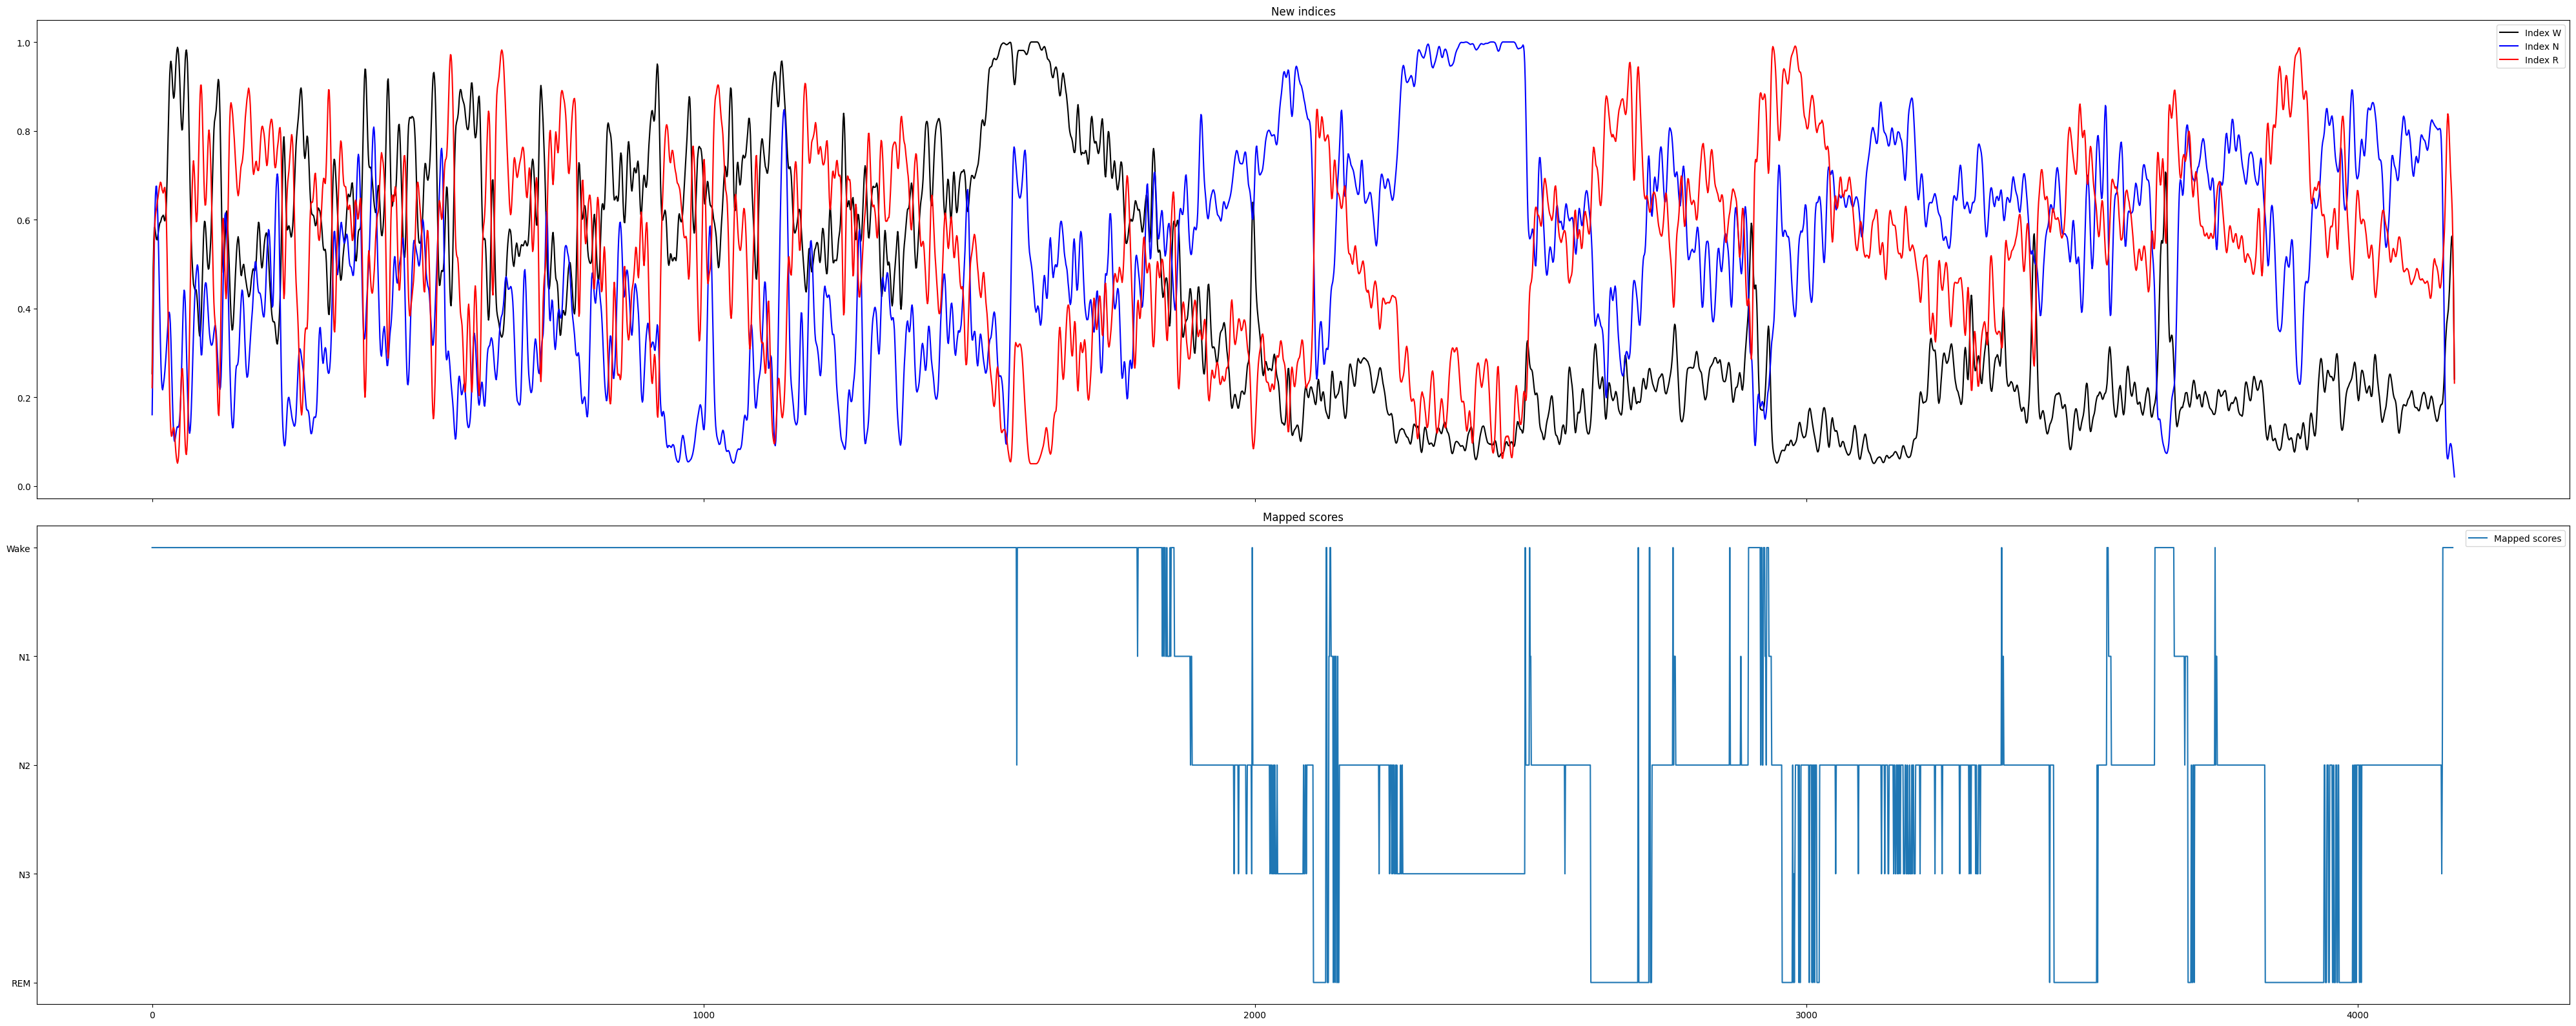

In [24]:
# All main indices
times = np.arange(0, len(epochs))
hypno_times = np.arange(0, len(hypno_epochs))
fig, (ax1, ax2) = plt.subplots(2, 1, sharex=True, figsize = (40, 16))

ax1.plot(epochs[times], index_w_smoothed[times], label='Index W', color='black')
ax1.plot(epochs[times], index_n_smoothed[times], label='Index N', color='blue')
ax1.plot(epochs[times], index_r_smoothed[times], label='Index R', color='red')

ax2.plot(hypno_epochs[hypno_times], mapped_scores[hypno_times], label='Mapped scores')

# Add legends
ax1.legend()
ax2.legend()

# Add titles
ax1.set_title('New indices')
ax2.set_title('Mapped scores')
ax2.set_yticks([0, 1, 2, 3, 4])
ax2.set_yticklabels(state_labels)
ax2.invert_yaxis()
# Adjust layout to avoid overlap
plt.tight_layout()
plt.savefig(f'{output_dir}/all_new_indices_vs_wei.svg', format='svg')
# Show the plots
plt.show()

In [30]:
index_Wake = [[],[],[],[]]
index_n1 = [[],[],[],[]]
index_n2 = [[],[],[],[]]
index_n3 = [[],[],[],[]]
index_REM = [[],[],[],[]]
score_labels = {0: 'Wake', 1: 'N1', 2: 'N2', 3: 'N3', 4: 'REM'}
mapped_scores_old = mapped_scores
mapped_scores = [score_labels[s] for s in mapped_scores]
for i, el in enumerate(mapped_scores):

  if el == 'Wake':
    index_Wake[0].append(index_w_smoothed[i])
    index_Wake[1].append(index_r_smoothed[i])
    index_Wake[2].append(index_n_smoothed[i])

  elif el == 'N1':
    index_n1[0].append(index_w_smoothed[i])
    index_n1[1].append(index_r_smoothed[i])
    index_n1[2].append(index_n_smoothed[i])
  elif el == 'N2':
    index_n2[0].append(index_w_smoothed[i])
    index_n2[1].append(index_r_smoothed[i])
    index_n2[2].append(index_n_smoothed[i])
  elif el == 'N3':
    index_n3[0].append(index_w_smoothed[i])
    index_n3[1].append(index_r_smoothed[i])
    index_n3[2].append(index_n_smoothed[i])
  elif el == 'REM':
    index_REM[0].append(index_w_smoothed[i])
    index_REM[1].append(index_r_smoothed[i])
    index_REM[2].append(index_n_smoothed[i])
    
wake_w = np.average(index_Wake[0])
wake_r = np.average(index_Wake[1])
wake_n = np.average(index_Wake[2])
n1_w = np.average(index_n1[0])
n1_r = np.average(index_n1[1])
n1_n = np.average(index_n1[2])
n2_w = np.average(index_n2[0])
n2_r = np.average(index_n2[1])
n2_n = np.average(index_n2[2])
n3_w = np.average(index_n3[0])
n3_r = np.average(index_n3[1])
n3_n = np.average(index_n3[2])
REM_w = np.average(index_REM[0])
REM_r = np.average(index_REM[1])
REM_n = np.average(index_REM[2])
if 'Wake' not in mapped_scores:
  nwake_w = 0
  nwake_r = 0
  nwake_n = 0
if 'REM' not in mapped_scores:
  nREM_w = 0
  nREM_r = 0
  nREM_n = 0
if 'N1' not in mapped_scores:
  nNREM_w = 0
  nNREM_r = 0
  nNREM_n = 0
if 'N2' not in mapped_scores:
  nNREM_w = 0
  nNREM_r = 0
  nNREM_n = 0
if 'N3' not in mapped_scores:
  nNREM_w = 0
  nNREM_r = 0
  nNREM_n = 0


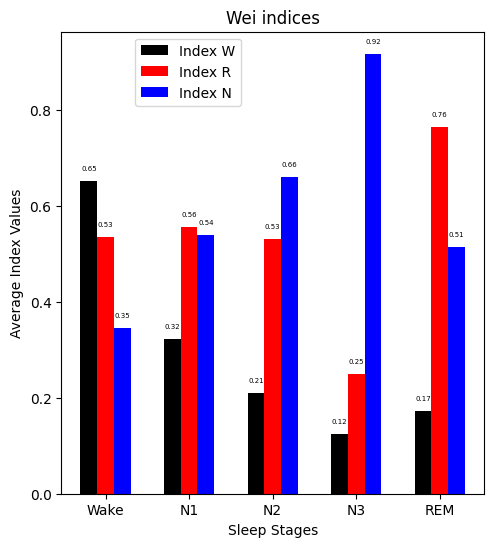

In [31]:
plt.figure(figsize=(12, 6))
fontsize = 5
# Wei indexes
plt.subplot(1, 2, 1)
categories = ['Wake', 'N1', 'N2','N3', 'REM']
index_types = ['Index_w', 'Index_r', 'Index_n', 'Index_New_NREM']
values_wake = [wake_w, n1_w, n2_w, n3_w, REM_w]
values_REM = [wake_r, n1_r, n2_r, n3_r, REM_r]
values_NREM = [wake_n, n1_n, n2_n, n3_n, REM_n]
x = np.arange(len(categories))
bar_width = 0.2
# Create bar plots
plt.bar(x - bar_width, values_wake, width=bar_width, label='Index W', color = 'black')
plt.bar(x, values_REM, width=bar_width, label='Index R', color = 'red',)
plt.bar(x + bar_width, values_NREM, width=bar_width, label='Index N', color = 'blue')
# Add labels and title
plt.xlabel('Sleep Stages')
plt.ylabel('Average Index Values')
plt.title('Wei indices')
plt.xticks(x, categories)
plt.legend(loc='upper center', bbox_to_anchor=(0.3, 1))

for i in range(len(categories)):
    plt.text(x[i] - bar_width, values_wake[i] + 0.02, str(round(values_wake[i], 2)), ha='center', va='bottom', fontsize=fontsize)
    plt.text(x[i], values_REM[i] + 0.02, str(round(values_REM[i], 2)), ha='center', va='bottom', fontsize=fontsize)
    plt.text(x[i] + bar_width, values_NREM[i] + 0.02, str(round(values_NREM[i], 2)), ha='center', va='bottom', fontsize=fontsize)

PCA data points:(4173, 3)


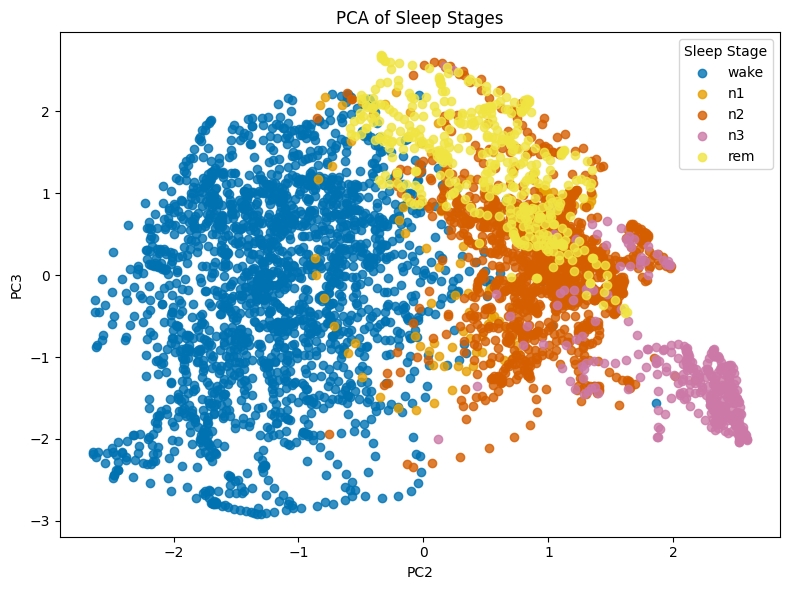

In [35]:
# mapped_scores_old = np.append(mapped_scores_old, [0,0])
difference = len(index_n_smoothed) - len(mapped_scores_old)
arrays = [
    index_w_smoothed[:-difference],
    index_r_smoothed[:-difference],
    index_n_smoothed[:-difference],
    mapped_scores_old
]
# print(f'epochs: {X.shape}')   # rows = number of samples (dots), columns = features
stage_map = {
    0.0: "wake",
    1.0: "n1",
    2.0: "n2",
    3.0: "n3",
    4.0: "rem"
}
array = np.column_stack(arrays)
df = pd.DataFrame(array)

x = df[[0, 1, 2]]
y = df[3]

scaler = StandardScaler()
X = x.to_numpy().astype(float)

# Replace NaNs with 0 (or another strategy like forward-fill)
X = np.nan_to_num(X, nan=0.0)
X_scaled = scaler.fit_transform(X)


pca = PCA(n_components=3)
X_pca = pca.fit_transform(X_scaled)

print(f'PCA data points:{X_pca.shape}')
# Colorblind-friendly palette
colors = ['#0072B2', '#E69F00', '#D55E00', '#CC79A7', '#F0E442']

plt.figure(figsize=(8,6))
for i, label in enumerate(np.unique(y)):
    stage_name = stage_map.get(label, str(label))  # fallback in case of unexpected value
    plt.scatter(
        X_pca[y==label, 0],
        X_pca[y==label, 1],
        label=stage_name,
        color=colors[i % len(colors)],
        alpha=0.8
    )

plt.xlabel("PC2")
plt.ylabel("PC3")
plt.title("PCA of Sleep Stages")
plt.legend(title="Sleep Stage")
plt.tight_layout()
plt.savefig(f"{output_dir}/Index_PCA_subject_2.svg", format='svg')
plt.show()